# Analyse de l'Incertitude des LLMs via LLM as a Judge
## Dataset: WebQuestions - Modèle: candidat : Qwen/Qwen2.5-1.5B-Instruct, juge : Qwen/Qwen2.5-7B-Instruct

**Objectifs:**
- Génération de texte libre et jugement de la réponse via un autre LLM
- Visualisation de statistiques concernant la réponse et la pertinence du jugement du LLM juge
- Etude du scénario de l'inversion des LLM candidats et juge

## 1 - Installation des LLM et librairies utilisées

In [1]:
!pip install -q transformers accelerate datasets pandas numpy scipy tqdm scikit-learn matplotlib seaborn sentencepiece rapidfuzz
print("Installation terminée")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 31.9 MB/s eta 0:00:00a 0:00:01
Installation terminée


In [2]:
# If needed:
# !pip -q install datasets transformers accelerate sentencepiece rapidfuzz

import re
import random
from typing import List, Dict
import pandas as pd
from tqdm.auto import tqdm

from datasets import load_dataset
from transformers import pipeline
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM


try:
    from rapidfuzz import fuzz
    RAPIDFUZZ_AVAILABLE = True
except Exception:
    RAPIDFUZZ_AVAILABLE = False


2026-02-08 21:17:27.591733: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770585447.786015      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770585447.845628      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770585448.338455      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770585448.338510      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770585448.338514      55 computation_placer.cc:177] computation placer alr

In [3]:
# Choose your models (non-FLAN)
LLM1_MODEL = "Qwen/Qwen2.5-1.5B-Instruct"   # ~1.5B (candidate)
LLM2_MODEL = "Qwen/Qwen2.5-7B-Instruct"    # ~7B  (judge)

def load_chat_model(model_name: str):
    tokenizer = AutoTokenizer.from_pretrained(
        model_name,
        use_fast=True,
        trust_remote_code=True,
    )

    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        device_map="auto",
        torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
        trust_remote_code=True,
    )

    model.eval()
    return tokenizer, model

tok1, model1 = load_chat_model(LLM1_MODEL)
tok2, model2 = load_chat_model(LLM2_MODEL)


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

...

model-00002-of-00004.safetensors:   0%|          | 0.00/3.86G [00:00<?, ?B/s]

model-00001-of-00004.safetensors:   0%|          | 0.00/3.95G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/3.56G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

## 2 - Scénario 1: LLM le plus puissant comme juge

Le code ci dessous sélectionne 200 questions de notre dataset au hasard

In [4]:
def load_webquestions_sample(n: int = 200, seed: int = 42) -> pd.DataFrame:
    random.seed(seed)
    ds = load_dataset("web_questions")

    split = "test" if "test" in ds else ("train" if "train" in ds else list(ds.keys())[0])
    data = ds[split]

    if "question" not in data.column_names:
        raise RuntimeError(f"Expected 'question'. Found: {data.column_names}")
    if "answers" not in data.column_names:
        raise RuntimeError(f"Expected 'answers'. Found: {data.column_names}")

    idxs = list(range(len(data)))
    random.shuffle(idxs)
    idxs = idxs[:n]

    rows = []
    for i in idxs:
        q = str(data[i]["question"]).strip()
        a = data[i]["answers"]

        answers: List[str] = []
        if isinstance(a, list):
            for item in a:
                if isinstance(item, str):
                    answers.append(item)
                elif isinstance(item, dict):
                    for k in ["answer", "text", "value", "label"]:
                        if k in item and isinstance(item[k], str):
                            answers.append(item[k])
                            break
                else:
                    answers.append(str(item))
        else:
            answers = [str(a)]

        answers = [x.strip() for x in answers if x and str(x).strip()]
        rows.append({"question": q, "answers": answers})

    return pd.DataFrame(rows)

df = load_webquestions_sample(seed=42)
df.head()


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/260k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/142k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3778 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2032 [00:00<?, ? examples/s]

,question,answers
0,when was the last time the toronto maple leafs...,[1949 Stanley Cup Finals]
1,who was president after william henry harrison?,[John Tyler]
2,what money does spain use?,[Euro]
3,what influenced william shakespeare to start w...,"[Thomas More, Ovid, Geoffrey Chaucer, Plutarch..."
4,what time zone is anaheim california?,[Pacific Time Zone]


Ci-dessous le prompt utilisé pour le LLM candidat et le LLM juge

In [5]:
LLM1_PROMPT = """You are a concise QA system.
Answer with a short factual phrase (no explanation).

Question: {q}
Answer:"""

LLM2_JUDGE_PROMPT = """You are a strict evaluator.

Decide whether the ANSWER correctly answers the QUESTION.

Reply with exactly ONE word:
Vrai
or
Faux

QUESTION: {q}

ANSWER: {a}

Is the answer correct?"""


Ci dessous certaines fonctions utilitaires : 
- Une fonction de traitement de texte
- Une fonction de comparaison de réponse générée avec la vraie réponse 
- Une focntion faisant appel au LLM pour générer une réponse 

In [6]:
def normalize_text(s: str) -> str:
    s = s.lower().strip()
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"[^\w\s]", "", s)
    return s

def is_correct_against_gold(pred: str, gold_answers: List[str]) -> bool:
    p = normalize_text(pred)
    gold_norm = [normalize_text(g) for g in gold_answers if g]

    if not p or not gold_norm:
        return False

    if p in gold_norm:
        return True

    for g in gold_norm:
        if p in g or g in p:
            return True

    if RAPIDFUZZ_AVAILABLE:
        for g in gold_norm:
            if fuzz.ratio(p, g) >= 90:
                return True

    return False

def parse_vrai_faux(text: str) -> str:
    t = text.strip().lower()
    if "vrai" in t and "faux" not in t:
        return "Vrai"
    if "faux" in t and "vrai" not in t:
        return "Faux"
    tok = re.split(r"\s+", t)[0]
    if tok.startswith("v"):
        return "Vrai"
    if tok.startswith("f"):
        return "Faux"
    return "Faux"

@torch.inference_mode()
def run_textgen_chat(tok, model, system: str, user: str, max_new_tokens: int = 32) -> str:
    messages = [
        {"role": "system", "content": system},
        {"role": "user", "content": user},
    ]
    prompt = tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tok(prompt, return_tensors="pt").to(model.device)

    out = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        temperature=0.0,
        eos_token_id=tok.eos_token_id,
    )

    gen_ids = out[0, inputs["input_ids"].shape[1]:]
    return tok.decode(gen_ids, skip_special_tokens=True).strip()


Ci-dessous le code stockant la réponse du LLM candidat et du LLM juge 

In [7]:
LLM1_SYSTEM = "Answer with a short factual phrase. No explanation."
LLM2_SYSTEM = """You are a strict evaluator.
Reply with exactly one word: Vrai or Faux. No punctuation, no explanation."""

results = []
for row in tqdm(df.to_dict("records"), total=len(df)):
    q = row["question"]
    gold = row["answers"]

    ans1 = run_textgen_chat(tok1, model1, LLM1_SYSTEM, f"Question: {q}\nAnswer:", max_new_tokens=24)
    gt_correct = is_correct_against_gold(ans1, gold)

    judge_raw = run_textgen_chat(tok2, model2, LLM2_SYSTEM, f"QUESTION: {q}\nANSWER: {ans1}\nJudgment:", max_new_tokens=10)
    judge = parse_vrai_faux(judge_raw)

    results.append({
        "question": q,
        "gold_answers": gold,
        "llm1_answer": ans1,
        "gt_correct": gt_correct,
        "llm2_judge": judge,
        "llm2_raw": judge_raw,
    })

res = pd.DataFrame(results)
res.head()


  0%|          | 0/200 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


,question,gold_answers,llm1_answer,gt_correct,llm2_judge,llm2_raw
0,when was the last time the toronto maple leafs...,[1949 Stanley Cup Finals],2019,False,Faux,Faux
1,who was president after william henry harrison?,[John Tyler],john tyler,True,Vrai,Vrai
2,what money does spain use?,[Euro],Euro,True,Vrai,Vrai
3,what influenced william shakespeare to start w...,"[Thomas More, Ovid, Geoffrey Chaucer, Plutarch...",financial difficulties and desire for recognit...,False,Vrai,Vrai
4,what time zone is anaheim california?,[Pacific Time Zone],Pacific Time Zone,True,Vrai,Vrai


Le code suivant calcule : 
- L'accuracy du LLM1
- L'accuracy du jugement LLM2 : sur quel degré le LLM2 (juge) permet de corriger le LLM1
- L'accuracy perçue par LLM2 : ce que le LLM2 perçoit comme accuracy après son jugement.

In [8]:
acc_llm1 = res["gt_correct"].mean()

res["llm2_pred_correct"] = res["llm2_judge"].eq("Vrai")
acc_judge = (res["llm2_pred_correct"] == res["gt_correct"]).mean()
acc_perceived = res["llm2_pred_correct"].mean()

print("Accuracy LLM1:", acc_llm1)
print("Accuracy du jugement LLM2:", acc_judge)
print("Accuracy perçue par LLM2:", acc_perceived)


Accuracy LLM1: 0.4
Accuracy du jugement LLM2: 0.67
Accuracy perçue par LLM2: 0.6


In [9]:
tp = int(((res["gt_correct"] == True) & (res["llm2_pred_correct"] == True)).sum())
tn = int(((res["gt_correct"] == False) & (res["llm2_pred_correct"] == False)).sum())
fp = int(((res["gt_correct"] == False) & (res["llm2_pred_correct"] == True)).sum())
fn = int(((res["gt_correct"] == True) & (res["llm2_pred_correct"] == False)).sum())

report = pd.DataFrame([{
    "N": len(res),
    "Accuracy LLM1": acc_llm1,
    "Accuracy jugement LLM2": acc_judge,
    "Accuracy perçue par LLM2": acc_perceived,
    "TP": tp, "TN": tn, "FP": fp, "FN": fn
}])
report


,N,Accuracy LLM1,Accuracy jugement LLM2,Accuracy perçue par LLM2,TP,TN,FP,FN
0,200,0.4,0.67,0.6,67,67,53,13


Un échantillon des erreurs effectuées par le LLM2

In [10]:
# Judge mistakes
judge_errors = res[res["llm2_pred_correct"] != res["gt_correct"]]
judge_errors[["question", "llm1_answer", "gold_answers", "gt_correct", "llm2_judge", "llm2_raw"]].head(30)

,question,llm1_answer,gold_answers,gt_correct,llm2_judge,llm2_raw
3,what influenced william shakespeare to start w...,financial difficulties and desire for recognit...,"[Thomas More, Ovid, Geoffrey Chaucer, Plutarch...",False,Vrai,Vrai
7,what has angelina jolie accomplished?,"Actress, humanitarian, producer, and activist.",[Golden Globe Award for Best Supporting Actres...,False,Vrai,Vrai
11,what is newt gingrich's wife's name?,Tina Gingrich,[Callista Gingrich],False,Vrai,Vrai
12,what produce does florida export?,"Oranges, strawberries, pineapples, tomatoes.",[Orange juice],False,Vrai,Vrai
13,where is the national ffa foundation located t...,The National FFA Foundation is headquartered i...,[Indianapolis],False,Vrai,Vrai
16,who is michael j fox parents?,Michael J Fox's parents are Virginia and Willi...,"[Phyllis Piper, William Fox]",True,Faux,Faux
22,who is president of israel?,Reuven Rivlin,[Shimon Peres],False,Vrai,Vrai
23,what did warren buffett invest in?,Warren Buffett invested in Coca-Cola.,[Berkshire Hathaway],False,Vrai,Vrai
25,what city and state is yale located in?,"Connecticut, United States.",[Connecticut],True,Faux,Faux
28,what county is brentwood tennessee in?,"Sumner County, Tennessee",[Williamson County],False,Vrai,Vrai


Visualisation de la matrice de confusion

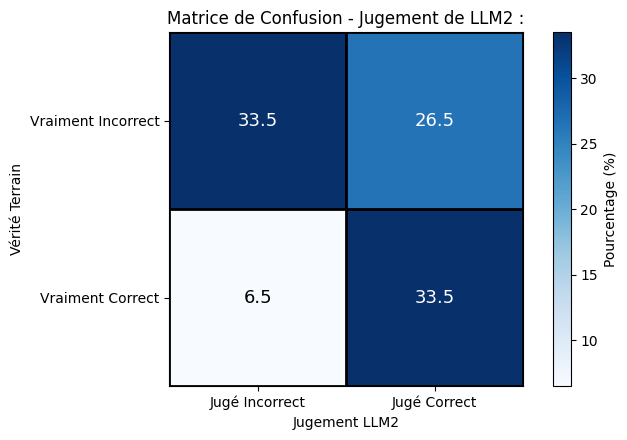

{'TN': 67, 'FP': 53, 'FN': 13, 'TP': 67}

In [ ]:
# --- Confusion matrix plot  (percentages + colorbar) ---
import numpy as np
import matplotlib.pyplot as plt

def plot_judge_confusion_matrix(res, title=None, as_percent=True, savepath=None):
    """
    res must contain:
      - gt_correct: bool (ground truth correctness of LLM1 answer)
      - llm2_pred_correct: bool (LLM2 judged answer correct)
    """
    gt = res["gt_correct"].astype(bool).to_numpy()
    pred = res["llm2_pred_correct"].astype(bool).to_numpy()

    # Confusion counts
    tn = np.sum((gt == False) & (pred == False))
    fp = np.sum((gt == False) & (pred == True))
    fn = np.sum((gt == True) & (pred == False))
    tp = np.sum((gt == True) & (pred == True))

    cm = np.array([[tn, fp],
                   [fn, tp]], dtype=float)

    if as_percent:
        cm_plot = (cm / cm.sum()) * 100.0 if cm.sum() > 0 else cm
        cbar_label = "Pourcentage (%)"
        fmt = "{:.1f}"
    else:
        cm_plot = cm
        cbar_label = "Comptes"
        fmt = "{:.0f}"

    fig, ax = plt.subplots(figsize=(7, 4.5))
    im = ax.imshow(cm_plot, cmap="Blues")

    # Annotate cells with adaptive text color
    for i in range(2):
        for j in range(2):
            val = cm_plot[i, j]
            ax.text(
                j, i, f"{val:.1f}",
                ha="center", va="center",
                fontsize=13,
                color="white" if val > cm_plot.max() * 0.5 else "black"
            )


    # Axis labels / ticks (French like your figure)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Jugé Incorrect", "Jugé Correct"])
    ax.set_yticklabels(["Vraiment Incorrect", "Vraiment Correct"])
    ax.set_xlabel("Jugement LLM2")
    ax.set_ylabel("Vérité Terrain")


    # Thick borders between cells (to match style)
    ax.set_xticks(np.arange(-.5, 2, 1), minor=True)
    ax.set_yticks(np.arange(-.5, 2, 1), minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=2)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Title + colorbar
    if title is None:
        title = "Matrice de Confusion - Jugement de LLM2"
    ax.set_title(title)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(cbar_label)

    plt.tight_layout()

    if savepath:
        plt.savefig(savepath, dpi=200, bbox_inches="tight")
    plt.show()

    return {"TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp)}


res["llm2_pred_correct"] = res["llm2_judge"].eq("Vrai")
plot_judge_confusion_matrix(
     res,
     title="Matrice de Confusion - Jugement de LLM2 :",
     as_percent=True
)


Visualisation du rapport de classification 

In [12]:
from sklearn.metrics import classification_report

y_true = res["gt_correct"].astype(int)
y_pred = res["llm2_pred_correct"].astype(int)

print(classification_report(
    y_true,
    y_pred,
    target_names=["Incorrect", "Correct"],
    digits=3
))


              precision    recall  f1-score   support

   Incorrect      0.838     0.558     0.670       120
     Correct      0.558     0.838     0.670        80

    accuracy                          0.670       200
   macro avg      0.698     0.698     0.670       200
weighted avg      0.726     0.670     0.670       200



# Scénario 2 : LLM le moins puissant comme juge

In [13]:
# ==============================
# Inverted roles: LLM2 answers, LLM1 judges
# ==============================

results_inv = []

for row in tqdm(df.to_dict("records"), total=len(df)):
    q = row["question"]
    gold = row["answers"]

    # LLM2 becomes candidate
    ans2 = run_textgen_chat(
        tok2, model2,
        LLM1_SYSTEM,
        f"Question: {q}\nAnswer:",
        max_new_tokens=24
    )

    gt_correct = is_correct_against_gold(ans2, gold)

    # LLM1 becomes judge
    judge_raw = run_textgen_chat(
        tok1, model1,
        LLM2_SYSTEM,
        f"QUESTION: {q}\nANSWER: {ans2}\nJudgment:",
        max_new_tokens=10
    )

    judge = parse_vrai_faux(judge_raw)

    results_inv.append({
        "question": q,
        "gold_answers": gold,
        "candidate_answer": ans2,
        "gt_correct": gt_correct,
        "judge_raw": judge_raw,
        "judge": judge,
    })

res_inv = pd.DataFrame(results_inv)
res_inv["judge_pred_correct"] = res_inv["judge"].eq("Vrai")

res_inv.head()


  0%|          | 0/200 [00:00<?, ?it/s]

,question,gold_answers,candidate_answer,gt_correct,judge_raw,judge,judge_pred_correct
0,when was the last time the toronto maple leafs...,[1949 Stanley Cup Finals],2023,False,Faux,Faux,False
1,who was president after william henry harrison?,[John Tyler],John Tyler,True,Vrai,Vrai,True
2,what money does spain use?,[Euro],Euro,True,Vrai,Vrai,True
3,what influenced william shakespeare to start w...,"[Thomas More, Ovid, Geoffrey Chaucer, Plutarch...",London's theatrical environment and classical ...,False,Vrai,Vrai,True
4,what time zone is anaheim california?,[Pacific Time Zone],Pacific Time Zone,True,Vrai,Vrai,True


In [14]:
acc_candidate_inv = res_inv["gt_correct"].mean()
acc_judge_inv = (res_inv["judge_pred_correct"] == res_inv["gt_correct"]).mean()
acc_perceived_inv = res_inv["judge_pred_correct"].mean()

tp = int(((res_inv["gt_correct"] == True) & (res_inv["judge_pred_correct"] == True)).sum())
tn = int(((res_inv["gt_correct"] == False) & (res_inv["judge_pred_correct"] == False)).sum())
fp = int(((res_inv["gt_correct"] == False) & (res_inv["judge_pred_correct"] == True)).sum())
fn = int(((res_inv["gt_correct"] == True) & (res_inv["judge_pred_correct"] == False)).sum())

pd.DataFrame([{
    "N": len(res_inv),
    "Accuracy Candidate": acc_candidate_inv,
    "Accuracy Judge": acc_judge_inv,
    "Accuracy perçue": acc_perceived_inv,
    "TP": tp, "TN": tn, "FP": fp, "FN": fn
}])


,N,Accuracy Candidate,Accuracy Judge,Accuracy perçue,TP,TN,FP,FN
0,200,0.455,0.625,0.73,81,44,65,10


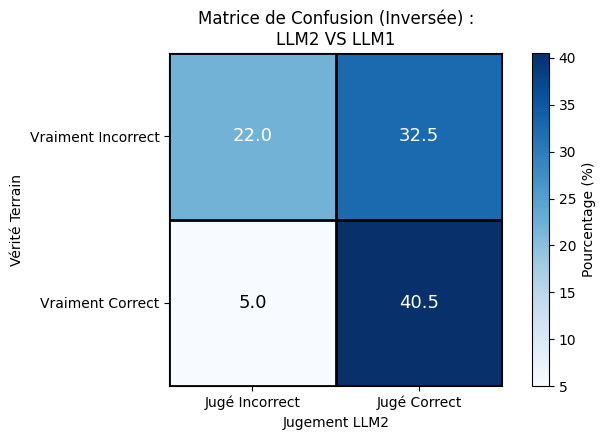

{'TN': 44, 'FP': 65, 'FN': 10, 'TP': 81}

In [15]:
plot_judge_confusion_matrix(
    res_inv.rename(columns={"judge_pred_correct": "llm2_pred_correct"}),
    title="Matrice de Confusion (Inversée) :\nLLM2 VS LLM1",
    as_percent=True
)


In [16]:
from sklearn.metrics import classification_report

y_true = res_inv["gt_correct"].astype(int)
y_pred = res_inv["judge_pred_correct"].astype(int)

print(classification_report(
    y_true,
    y_pred,
    target_names=["Incorrect", "Correct"],
    digits=3
))


              precision    recall  f1-score   support

   Incorrect      0.815     0.404     0.540       109
     Correct      0.555     0.890     0.684        91

    accuracy                          0.625       200
   macro avg      0.685     0.647     0.612       200
weighted avg      0.697     0.625     0.605       200

